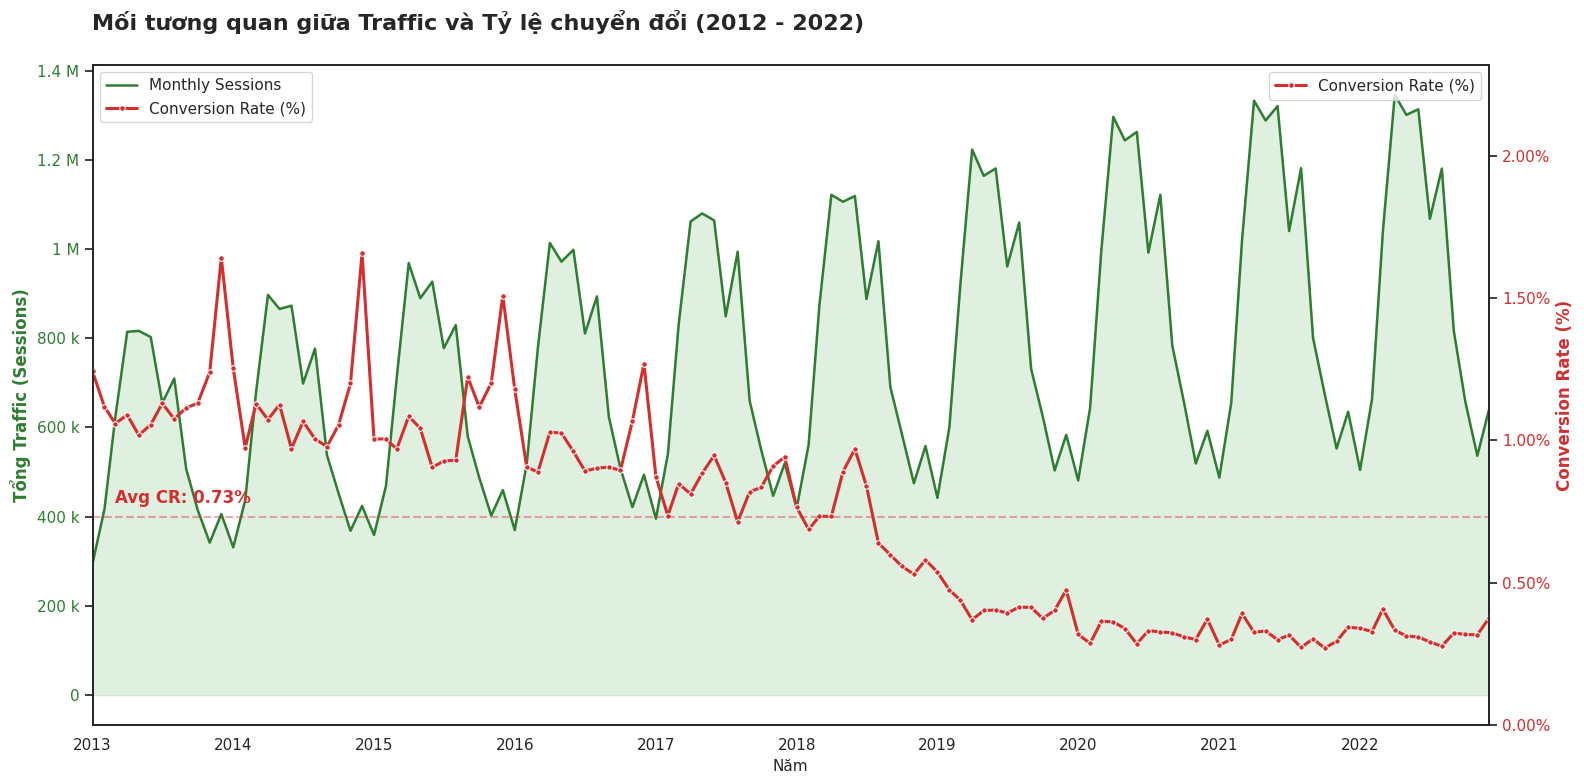

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import os

# 1. SETUP PATHS
root_dir = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
processed_dir = os.path.join(root_dir, "data", "processed")

def run_full_conversion_analysis():
    # --- STEP 1: LOAD DATA ---
    try:
        traffic = pd.read_parquet(os.path.join(processed_dir, "web_traffic.parquet"))
        orders = pd.read_parquet(os.path.join(processed_dir, "orders.parquet"))
    except Exception as e:
        print(f"Lỗi load file: {e}")
        return

    # --- STEP 2: XỬ LÝ DỮ LIỆU TRAFFIC ---
    # Chuyển cột date về datetime và lọc bỏ data lọt sang 2023
    traffic['date'] = pd.to_datetime(traffic['date'])
    traffic = traffic[traffic['date'].dt.year <= 2022]
    
    # Gom nhóm theo ngày
    daily_traffic = traffic.groupby(traffic['date'].dt.date).agg(
        total_sessions=('sessions', 'sum'),
        total_visitors=('unique_visitors', 'sum')
    ).reset_index()
    daily_traffic.rename(columns={'date': 'date_key'}, inplace=True)

    # --- STEP 3: XỬ LÝ DỮ LIỆU ORDERS ---
    order_date_col = 'order_date' if 'order_date' in orders.columns else 'Date'
    orders['date'] = pd.to_datetime(orders[order_date_col]).dt.date
    
    daily_orders = orders.groupby('date').agg(
        actual_orders=('order_id', 'nunique')
    ).reset_index()
    daily_orders.rename(columns={'date': 'date_key'}, inplace=True)

    # --- STEP 4: MERGE & TÍNH CR ---
    df_final = pd.merge(daily_traffic, daily_orders, on='date_key', how='left').fillna(0)
    df_final['conversion_rate'] = np.where(
        df_final['total_sessions'] > 0, 
        (df_final['actual_orders'] / df_final['total_sessions']) * 100, 
        0
    )
    
    # Chuyển lại cột date_key sang datetime để Resample
    df_final['date_key'] = pd.to_datetime(df_final['date_key'])
    
    # --- STEP 5: RESAMPLE THEO THÁNG ĐỂ VẼ CHART ---
    monthly_df = df_final.resample('MS', on='date_key').agg({
        'total_sessions': 'sum',
        'actual_orders': 'sum'
    }).reset_index()
    
    monthly_df['conversion_rate'] = (monthly_df['actual_orders'] / monthly_df['total_sessions']) * 100
    monthly_df = monthly_df.fillna(0)

    # --- STEP 6: VẼ BIỂU ĐỒ (CHART 2A) ---
    sns.set_theme(style="white", font="DejaVu Sans")
    fig, ax1 = plt.subplots(figsize=(16, 8))
    fig.patch.set_facecolor('white')

    # Trục Y1: Traffic
    color_sessions = '#81C784' 
    ax1.fill_between(monthly_df['date_key'], monthly_df['total_sessions'], color=color_sessions, alpha=0.25)
    ax1.plot(monthly_df['date_key'], monthly_df['total_sessions'], color='#2E7D32', lw=1.8, label='Monthly Sessions')
    
    ax1.set_xlabel('Năm', fontsize=11)
    ax1.set_ylabel('Tổng Traffic (Sessions)', fontsize=12, fontweight='bold', color='#2E7D32')
    ax1.tick_params(axis='y', labelcolor='#2E7D32')
    ax1.yaxis.set_major_formatter(mtick.EngFormatter())
    
    # Fix cứng trục X để không lố sang 2023
    ax1.set_xlim(monthly_df['date_key'].min(), monthly_df['date_key'].max())

    # Trục Y2: Conversion Rate
    ax2 = ax1.twinx()
    color_cr = '#D32F2F'
    sns.lineplot(x='date_key', y='conversion_rate', data=monthly_df, ax=ax2, 
                 color=color_cr, lw=2.2, marker='o', markersize=4, label='Conversion Rate (%)')
    
    ax2.set_ylabel('Conversion Rate (%)', fontsize=12, fontweight='bold', color=color_cr)
    ax2.tick_params(axis='y', labelcolor=color_cr)
    ax2.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))
    
    # Scale trục Y2 thoáng hơn
    ax2.set_ylim(0, monthly_df['conversion_rate'].max() * 1.4)

    # Title & Legend
    plt.title('Mối tương quan giữa Traffic và Tỷ lệ chuyển đổi (2012 - 2022)', 
              fontsize=16, fontweight='bold', pad=25, loc='left')
    
    avg_cr = monthly_df['conversion_rate'].mean()
    ax2.axhline(avg_cr, color=color_cr, linestyle='--', alpha=0.4)
    ax2.text(monthly_df['date_key'].iloc[2], avg_cr + 0.05, f'Avg CR: {avg_cr:.2f}%', 
             color=color_cr, fontweight='bold')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    plt.tight_layout()
    plt.show()

    return df_final

# Thực thi
df_story_2 = run_full_conversion_analysis()